## 加载中文字体

In [1]:
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import font_manager
import seaborn as sns
import os

# 1. 强制加载字体文件
font_path = r"C:\Windows\Fonts\msyh.ttc"
if not os.path.exists(font_path):
    font_path = r"C:\Windows\Fonts\simhei.ttf"

font_manager.fontManager.addfont(font_path)
font_prop = font_manager.FontProperties(fname=font_path)
font_name = font_prop.get_name()

print("Loaded font:", font_name)

# 2. 写入 matplotlib 全局
plt.rcParams["font.family"] = font_name
plt.rcParams["axes.unicode_minus"] = False

# 3. 写入 seaborn（这是你缺的）
sns.set_theme(
    style="white",
    rc={
        "font.family": font_name,
        "font.sans-serif": [font_name],
        "axes.unicode_minus": False
    }
)

# 4. 让已经存在的 figure 也刷新
matplotlib.rcParams["font.family"] = font_name


Loaded font: Microsoft YaHei


## 验证中文字体

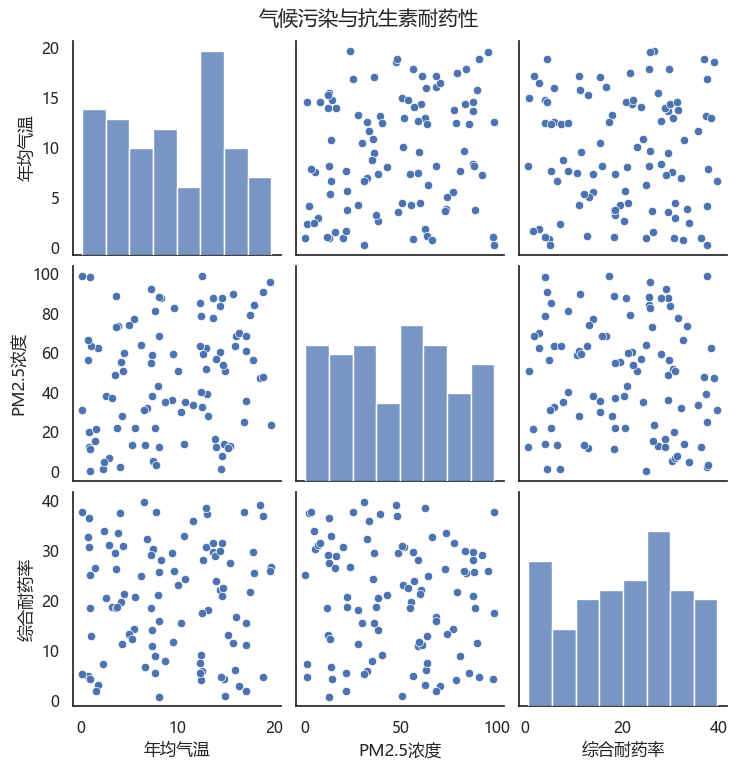

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

test = pd.DataFrame({
    "年均气温": np.random.rand(100)*20,
    "PM2.5浓度": np.random.rand(100)*100,
    "综合耐药率": np.random.rand(100)*40
})

g = sns.pairplot(test)
g.fig.suptitle("气候污染与抗生素耐药性", y=1.02)
plt.show()


## 1）Nature Medicine 风格矩阵图绘制函数（！）

In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

# sns.set_style("white")

def p_to_star(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return ""

def diag_kde(x, **kws):
    x = np.asarray(x)
    x = x[np.isfinite(x)]
    if len(x) >= 10 and np.std(x) > 0:
        sns.kdeplot(x=x, fill=True, alpha=0.25)
    else:
        plt.hist(x, bins=10, alpha=0.25)

def lower_scatter_group_reg(x, y, color=None, **kws):
    # seaborn PairGrid 会自动传入每一组的数据
    plt.scatter(x, y, s=8, alpha=0.25)

    x = np.asarray(x); y = np.asarray(y)
    m = np.isfinite(x) & np.isfinite(y)
    if m.sum() >= 10 and np.std(x[m]) > 0 and np.std(y[m]) > 0:
        b1, b0 = np.polyfit(x[m], y[m], 1)
        xs = np.linspace(np.min(x[m]), np.max(x[m]), 60)
        plt.plot(xs, b1*xs + b0, linewidth=1)

def upper_corr_text(x, y, **kws):
    ax = plt.gca()
    ax.axis("off")
    x = np.asarray(x); y = np.asarray(y)
    m = np.isfinite(x) & np.isfinite(y)
    if m.sum() >= 10 and np.std(x[m]) > 0 and np.std(y[m]) > 0:
        r, p = stats.pearsonr(x[m], y[m])
        ax.text(0.05, 0.68, f"Corr: {r:.3f}{p_to_star(p)}", transform=ax.transAxes, fontsize=9)

def upper_group_corr_text(data, x, y, group_col):
    """
    在上三角写：总体Corr + 分组Corr（H/UM/LM/L）
    """
    ax = plt.gca()
    ax.axis("off")

    # 总体
    xx = data[x].values
    yy = data[y].values
    m = np.isfinite(xx) & np.isfinite(yy)
    if m.sum() < 10 or np.std(xx[m]) == 0 or np.std(yy[m]) == 0:
        return
    r, p = stats.pearsonr(xx[m], yy[m])
    ax.text(0.03, 0.84, f"Corr: {r:.3f}{p_to_star(p)}", transform=ax.transAxes, fontsize=9, color="black")

    # 分组
    y0 = 0.62
    for gname, c in [("H", "tab:blue"), ("UM", "tab:orange"), ("LM", "tab:green"), ("L", "tab:red")]:
        sub = data[data[group_col] == gname]
        if len(sub) < 8:
            y0 -= 0.14
            continue
        xx = sub[x].values; yy = sub[y].values
        m = np.isfinite(xx) & np.isfinite(yy)
        if m.sum() >= 8 and np.std(xx[m]) > 0 and np.std(yy[m]) > 0:
            rr, pp = stats.pearsonr(xx[m], yy[m])
            ax.text(0.03, y0, f"{gname}: {rr:.3f}{p_to_star(pp)}", transform=ax.transAxes, fontsize=8, color=c)
        y0 -= 0.14

def nature_pairgrid(data, vars_list, group_col=None, title="", figsize=None):
    """
    生成 Nature Medicine 风格矩阵：
    - 对角：kde
    - 下三角：散点+回归线（分组）
    - 上三角：相关系数（总体 + 分组）
    """
    d = data[vars_list + ([group_col] if group_col else [])].copy()
    d = d.dropna(subset=vars_list)

    # 画布尺寸
    n = len(vars_list)
    if figsize is None:
        figsize = (max(10, 1.7*n), max(8, 1.6*n))

    if group_col:
        g = sns.PairGrid(d, vars=vars_list, hue=group_col, corner=False, diag_sharey=False, height=1.0)
        g.map_diag(diag_kde)
        g.map_lower(lower_scatter_group_reg)

        # 上三角：需要手动逐格写分组相关
        for i in range(n):
            for j in range(n):
                if j <= i:
                    continue
                ax = g.axes[i, j]
                plt.sca(ax)
                upper_group_corr_text(d, vars_list[j], vars_list[i], group_col)

        g.add_legend(title=group_col)
        g.fig.set_size_inches(figsize[0], figsize[1])
        g.fig.suptitle(title, y=1.02)
        plt.tight_layout()
        plt.show()

    else:
        g = sns.PairGrid(d, vars=vars_list, corner=False, diag_sharey=False, height=1.0)
        g.map_diag(diag_kde)
        g.map_lower(lower_scatter_group_reg)
        g.map_upper(upper_corr_text)
        g.fig.set_size_inches(figsize[0], figsize[1])
        g.fig.suptitle(title, y=1.02)
        plt.tight_layout()
        plt.show()


## 2）读取并合并两张表 + 生成分组 （按GDP四分位 H/UM/LM/L）

### ** Step 1｜分 AMR 的异质性分析 **

In [6]:
# =========================
# 0) 中文字体 + seaborn全局
# =========================
import os
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import font_manager
import seaborn as sns
from scipy import stats

# ---- 强制加载中文字体（Windows推荐微软雅黑） ----
font_path = r"C:\Windows\Fonts\msyh.ttc"
if not os.path.exists(font_path):
    font_path = r"C:\Windows\Fonts\simhei.ttf"
assert os.path.exists(font_path), "找不到中文字体文件，请检查 C:\\Windows\\Fonts"

font_manager.fontManager.addfont(font_path)
font_prop = font_manager.FontProperties(fname=font_path)
font_name = font_prop.get_name()
print("Loaded font:", font_name)

plt.rcParams["font.family"] = font_name
plt.rcParams["axes.unicode_minus"] = False
sns.set_theme(
    style="white",
    rc={"font.family": font_name, "font.sans-serif": [font_name], "axes.unicode_minus": False}
)
matplotlib.rcParams["font.family"] = font_name


# =========================
# 1) 读入 & 合并两张表
# =========================
amr_path = r"C:\Users\lunch\Downloads\amr_rate.csv"
x_path   = r"C:\Users\lunch\Downloads\climate_social_eco.csv"

amr = pd.read_csv(amr_path, encoding="utf-8-sig")
X   = pd.read_csv(x_path,   encoding="utf-8-sig")

amr.columns = [str(c).strip() for c in amr.columns]
X.columns   = [str(c).strip() for c in X.columns]

def rename_key(df):
    m={}
    for c in df.columns:
        s = str(c).strip()
        if s.lower() in ["province","省份"]: m[c] = "Province"
        if s.lower() in ["year","年份"] or s == "YEAR": m[c] = "Year"
    return df.rename(columns=m)

amr = rename_key(amr)
X   = rename_key(X)

amr["Province"] = amr["Province"].astype(str).str.strip()
X["Province"]   = X["Province"].astype(str).str.strip()
amr["Year"] = pd.to_numeric(amr["Year"], errors="coerce")
X["Year"]   = pd.to_numeric(X["Year"], errors="coerce")

amr = amr[(amr["Year"]>=2014)&(amr["Year"]<=2023)].copy()
X   = X[(X["Year"]>=2014)&(X["Year"]<=2023)].copy()

df = pd.merge(amr, X, on=["Province","Year"], how="inner")
df = df.dropna(subset=["Province","Year"]).copy()
df["Year"] = df["Year"].astype(int)
df = df.sort_values(["Province","Year"]).reset_index(drop=True)

# 13个AMR列（按你表头）
AMR_13 = ["MRCNS","VREFS","VREFM","PRSP","ERSP","3GCRKP","MRSA","3GCREC","CREC","QREC","CRPA","CRKP","CRAB"]
amr_cols = [c for c in AMR_13 if c in df.columns]
print("AMR cols found:", amr_cols)

# 所有数值列转float（避免 dtype 引起的坑）
key_cols = ["Province","Year"]
for c in [c for c in df.columns if c not in key_cols]:
    df[c] = pd.to_numeric(df[c], errors="coerce").astype("float64")


# =========================
# 2) 缺失值处理（X变量按省插值）
# =========================
# 仅对自变量做插值/填充，AMR保持原状（避免“造数据”）
# 你要分析的9个因素：用“包含关键词”自动找列名（中英皆可）
wanted_keywords = {
    "TA": ["气温","温度","TA","省平均气温"],
    "PA": ["降水","PA","省平均降水"],
    "R1xday": ["R1xday","R1x"],
    "PM25": ["PM2.5","PM25","颗粒物","细颗粒物"],
    "MED": ["医疗","卫生技术人员","医疗水平","health"],
    "GDP": ["GDP"],
    "WATER": ["用水","自来水","城市用水普及率","water"],
    "WASTE": ["垃圾","无害化","生活垃圾无害化","waste","生活垃圾无害化处理率"],
    "AMC": ["抗菌","抗生素","抗微生物","antimicrobial","用药强度","使用强度","抗菌药物使用强度"]
}

def find_col_by_keywords(columns, kws):
    for kw in kws:
        for c in columns:
            if kw in str(c):
                return c
    return None

selected_map = {}
for short, kws in wanted_keywords.items():
    col = find_col_by_keywords(df.columns, kws)
    selected_map[short] = col

print("Selected columns (auto-matched):")
for k,v in selected_map.items():
    print(f"  {k}: {v}")

# 如果有没匹配到的，你可以在这里手动指定
# 例如：selected_map["PM25"] = "颗粒物（14和15年是烟尘）"

selected_cols = [v for v in selected_map.values() if v is not None]
assert len(selected_cols) >= 5, "自动匹配到的自变量太少，请检查列名并手动指定 selected_map"

# 按省份-年份插值 + 省均值 + 全局中位数兜底
df = df.sort_values(["Province","Year"]).reset_index(drop=True)
for c in selected_cols:
    df[c] = df.groupby("Province")[c].transform(lambda s: s.interpolate(limit_direction="both"))
    df[c] = df[c].fillna(df.groupby("Province")[c].transform("mean"))
    df[c] = df[c].fillna(df[c].median())


# =========================
# 3) GDP分组（每年四分位：L/LM/UM/H）
# =========================
if selected_map.get("GDP") and selected_map["GDP"] in df.columns:
    gdp_col = selected_map["GDP"]
    df["Group"] = df.groupby("Year")[gdp_col].transform(lambda s: pd.qcut(s, 4, labels=["L","LM","UM","H"]))
    df["Group"] = df["Group"].astype(str)
else:
    df["Group"] = "All"


# =========================
# 4) Nature风格绘图组件
# =========================
def p_to_star(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return ""

def diag_kde(x, **kws):
    x = np.asarray(x)
    x = x[np.isfinite(x)]
    ax = plt.gca()
    if len(x) >= 10 and np.std(x) > 0:
        sns.kdeplot(x=x, fill=True, alpha=0.25, linewidth=1, ax=ax)
    else:
        ax.hist(x, bins=10, alpha=0.25)

def lower_scatter_group_reg(x, y, color=None, **kws):
    ax = plt.gca()
    ax.scatter(x, y, s=10, alpha=0.25)
    x = np.asarray(x); y = np.asarray(y)
    m = np.isfinite(x) & np.isfinite(y)
    if m.sum() >= 10 and np.std(x[m]) > 0 and np.std(y[m]) > 0:
        b1, b0 = np.polyfit(x[m], y[m], 1)
        xs = np.linspace(np.min(x[m]), np.max(x[m]), 60)
        ax.plot(xs, b1*xs + b0, linewidth=1)

def upper_group_corr_text(data, x, y, group_col):
    ax = plt.gca()
    ax.axis("off")

    xx = data[x].values
    yy = data[y].values
    m = np.isfinite(xx) & np.isfinite(yy)
    if m.sum() < 10 or np.std(xx[m]) == 0 or np.std(yy[m]) == 0:
        return

    r, p = stats.pearsonr(xx[m], yy[m])
    ax.text(0.03, 0.86, f"Corr: {r:.3f}{p_to_star(p)}", transform=ax.transAxes, fontsize=9, color="black")

    y0 = 0.64
    # 固定颜色顺序：H蓝 UM橙 LM绿 L红（跟你之前论文风格一致）
    group_order = [("H","tab:blue"), ("UM","tab:orange"), ("LM","tab:green"), ("L","tab:red")]
    for gname, c in group_order:
        sub = data[data[group_col] == gname]
        if len(sub) < 8:
            y0 -= 0.14
            continue
        sx = sub[x].values; sy = sub[y].values
        mm = np.isfinite(sx) & np.isfinite(sy)
        if mm.sum() >= 8 and np.std(sx[mm]) > 0 and np.std(sy[mm]) > 0:
            rr, pp = stats.pearsonr(sx[mm], sy[mm])
            ax.text(0.03, y0, f"{gname}: {rr:.3f}{p_to_star(pp)}", transform=ax.transAxes, fontsize=8, color=c)
        y0 -= 0.14

def save_one_pairgrid(data, vars_list, group_col, title, out_png):
    d = data[vars_list + [group_col]].dropna(subset=vars_list).copy()
    if len(d) < 60:
        print("[SKIP] too few rows:", out_png)
        return

    g = sns.PairGrid(d, vars=vars_list, hue=group_col, corner=False, diag_sharey=False, height=1.0)
    g.map_diag(diag_kde)
    g.map_lower(lower_scatter_group_reg)

    n = len(vars_list)
    for i in range(n):
        for j in range(n):
            if j <= i:
                continue
            ax = g.axes[i, j]
            plt.sca(ax)
            upper_group_corr_text(d, vars_list[j], vars_list[i], group_col)

    g.add_legend(title=group_col)
    g.fig.set_size_inches(max(10, 1.7*n), max(8, 1.6*n))
    g.fig.suptitle(title, y=1.02)
    plt.tight_layout()

    g.fig.savefig(out_png, dpi=300, bbox_inches="tight")
    plt.close(g.fig)
    print("Saved:", out_png)


# =========================
# 5) 对13个AMR逐个绘制并保存
#    变量顺序：你指定的9个因素（按我们匹配到的列名）
# =========================
# 画图时用的自变量（按你要的顺序）
plot_X = [
    selected_map["TA"], selected_map["PA"], selected_map["R1xday"],
    selected_map["PM25"], selected_map["MED"], selected_map["GDP"],
    selected_map["WATER"], selected_map["WASTE"], selected_map["AMC"]
]
plot_X = [c for c in plot_X if c is not None and c in df.columns]

# 去掉常数列（避免空图）
plot_X = [c for c in plot_X if np.nanstd(df[c].values) > 0]
print("Predictors used in plot:", plot_X)

out_dir = "AMR_selected9"
os.makedirs(out_dir, exist_ok=True)

for amr in amr_cols:
    title = f"{amr} 与 指定9因素（分组相关+趋势，Nature风格）"
    out_png = os.path.join(out_dir, f"{amr}_selected9.png")
    save_one_pairgrid(df, plot_X + [amr], "Group", title, out_png)


Loaded font: Microsoft YaHei
AMR cols found: ['MRCNS', 'VREFS', 'VREFM', 'PRSP', 'ERSP', '3GCRKP', 'MRSA', '3GCREC', 'CREC', 'QREC', 'CRPA', 'CRKP', 'CRAB']
Selected columns (auto-matched):
  TA: 主要城市平均气温
  PA: 主要城市降水量
  R1xday: R1xday
  PM25: PM2.5
  MED: 医疗水平
  GDP: GDP
  WATER: 城市用水普及率
  WASTE: 生活垃圾无害化处理率
  AMC: 抗菌药物使用强度
Predictors used in plot: ['主要城市平均气温', '主要城市降水量', 'R1xday', 'PM2.5', '医疗水平', 'GDP', '城市用水普及率', '生活垃圾无害化处理率', '抗菌药物使用强度']
Saved: AMR_selected9\MRCNS_selected9.png
Saved: AMR_selected9\VREFS_selected9.png
Saved: AMR_selected9\VREFM_selected9.png
Saved: AMR_selected9\PRSP_selected9.png
Saved: AMR_selected9\ERSP_selected9.png
Saved: AMR_selected9\3GCRKP_selected9.png
Saved: AMR_selected9\MRSA_selected9.png
Saved: AMR_selected9\3GCREC_selected9.png
Saved: AMR_selected9\CREC_selected9.png
Saved: AMR_selected9\QREC_selected9.png
Saved: AMR_selected9\CRPA_selected9.png
Saved: AMR_selected9\CRKP_selected9.png
Saved: AMR_selected9\CRAB_selected9.png


### *Step 2｜整体 AMR 的综合效应分析（AMR_AGG_z）*

1️⃣ 组合“整体 AMR”的变量列表

In [7]:
# 整体AMR用的自变量（严格限定为你指定的9个）
X_overall = [
    selected_map["TA"],
    selected_map["PA"],
    selected_map["R1xday"],
    selected_map["PM25"],
    selected_map["MED"],
    selected_map["GDP"],
    selected_map["WATER"],
    selected_map["WASTE"],
    selected_map["AMC"],
]

# 清理 None / 不存在 / 常数列
X_overall = [
    c for c in X_overall
    if c is not None and c in df.columns and np.nanstd(df[c].values) > 0
]

print("Overall AMR predictors:", X_overall)


Overall AMR predictors: ['主要城市平均气温', '主要城市降水量', 'R1xday', 'PM2.5', '医疗水平', 'GDP', '城市用水普及率', '生活垃圾无害化处理率', '抗菌药物使用强度']


2️⃣ 绘制 整体 AMR_AGG_z × 9 因素（Nature 主文级）
    AMR_AGG_z 的含义是：
    · 每一种 AMR 列先变成标准分（均值0方差1）
    · 再做平均
    这样每种菌的贡献更公平，比直接平均原始值更符合论文写法。

In [9]:
import numpy as np
import pandas as pd

# -----------------------------
# 0) 你13个AMR列名（按你表）
# -----------------------------
AMR_13 = ["MRCNS","VREFS","VREFM","PRSP","ERSP",
          "3GCRKP","MRSA","3GCREC","CREC",
          "QREC","CRPA","CRKP","CRAB"]

# 找到 df 里真实存在的AMR列
amr_cols = [c for c in AMR_13 if c in df.columns]
print("AMR cols found:", amr_cols)
assert len(amr_cols) >= 5, "df里没找到足够AMR列，请检查表头是否和AMR_13一致"

# -----------------------------
# 1) 生成 AMR_AGG_z（若不存在）
#    z-score: 每列减均值/除标准差（忽略缺失）
# -----------------------------
if "AMR_AGG_z" not in df.columns:
    # 确保为数值
    for c in amr_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    # 逐列zscore（pandas方式，不依赖sklearn，最稳）
    z_df = df[amr_cols].apply(lambda s: (s - s.mean()) / (s.std(ddof=0) if s.std(ddof=0) != 0 else np.nan))

    # 行均值（自动跳过NaN）
    df["AMR_AGG_z"] = z_df.mean(axis=1, skipna=True)

    print("✅ Created AMR_AGG_z")
else:
    print("✅ AMR_AGG_z already exists")

print(df[["AMR_AGG_z"]].describe())
print("NaN ratio:", df["AMR_AGG_z"].isna().mean())

# 如果 AMR_AGG_z 全是 NaN，说明13个AMR列全缺失或全常数
assert df["AMR_AGG_z"].notna().sum() > 0, "AMR_AGG_z 全是空值，请检查AMR数据列是否全为空/全一样"

# -----------------------------
# 2) 再画图（你之前那段整体绘图）
# -----------------------------
import os

out_dir = "AMR_OVERALL"
os.makedirs(out_dir, exist_ok=True)

title = "气候 / 污染 / 社会经济因素 与 综合耐药性（AMR_AGG_z）"
out_png = os.path.join(out_dir, "AMR_AGG_z_selected9.png")

# X_overall 请确保你上一步已经准备好（9个因素）
# 如果你怕X_overall里有None，这里再过滤一次：
X_overall_clean = [c for c in X_overall if (c is not None and c in df.columns)]
print("X_overall used:", X_overall_clean)

save_one_pairgrid(
    df,
    X_overall_clean + ["AMR_AGG_z"],
    group_col="Group",
    title=title,
    out_png=out_png
)


AMR cols found: ['MRCNS', 'VREFS', 'VREFM', 'PRSP', 'ERSP', '3GCRKP', 'MRSA', '3GCREC', 'CREC', 'QREC', 'CRPA', 'CRKP', 'CRAB']
✅ Created AMR_AGG_z
        AMR_AGG_z
count  307.000000
mean    -0.000093
std      0.592088
min     -1.375048
25%     -0.384427
50%     -0.139798
75%      0.353142
max      1.676874
NaN ratio: 0.00967741935483871
X_overall used: ['主要城市平均气温', '主要城市降水量', 'R1xday', 'PM2.5', '医疗水平', 'GDP', '城市用水普及率', '生活垃圾无害化处理率', '抗菌药物使用强度']
Saved: AMR_OVERALL\AMR_AGG_z_selected9.png


确认 Group 是否存在四组：

In [10]:
print(df["Group"].value_counts(dropna=False))


Group
LM    80
L     80
H     80
UM    70
Name: count, dtype: int64


解释 AMR_AGG_z：
本研究构建综合耐药性指标（AMR_AGG_z），具体做法为：对 13 类耐药菌检出率分别进行 z 标准化处理（均值为 0、标准差为 1），以消除不同耐药指标之间量纲和尺度差异；随后在省份—年份层面求均值，得到综合耐药性水平。该指标越大表示该省份在该年份的总体耐药性水平越高。